In [7]:
from collections import namedtuple
from typing import Tuple

import os
import subprocess
import pickle
import numpy as np
import matplotlib.pyplot as plt

#### Utilities

In [8]:
ColorsCounts = namedtuple("ColorsCounts", ["boyerMyrvold", "mst", "cactus"])
Times = namedtuple("Times", ["boyerMyrvold", "mst", "cactus"])

AverageResult = namedtuple(
    "AverageResult",
    ["basic", "weighted"]
)

TestResult = namedtuple(
    "TestResult", 
    ["colors", "times"]
)

In [9]:
def test_minimal_coloring(n0: int, n: int, m: int, reps: int) -> Tuple[TestResult, TestResult] | None:
    try:
        result = subprocess.run(
            ["../build/minimum_coloring", str(5), str(n0), str(m), str(n), str(reps)],
            check=True,
            capture_output=True,
            text=True,
        )
    except subprocess.CalledProcessError as e:
        print(f"Error generating graph: {e}")
        return None
    
    output_lines = result.stdout.strip().splitlines()
    if len(output_lines) < 2:
        print("Unexpected output format")
        return None

    color_values = list(map(float, output_lines[0].split()))
    color_mean = AverageResult(
        basic=ColorsCounts(color_values[0], color_values[4], color_values[8]),
        weighted=ColorsCounts(color_values[2], color_values[6], color_values[10])
    )
    color_std = AverageResult(
        basic=ColorsCounts(color_values[1], color_values[5], color_values[9]),
        weighted=ColorsCounts(color_values[3], color_values[7], color_values[11])
    )

    time_values = list(map(float, output_lines[1].split()))
    time_mean = AverageResult(
        basic=Times(time_values[0], time_values[4], time_values[8]),
        weighted=Times(time_values[2], time_values[6], time_values[10])
    )
    time_std = AverageResult(
        basic=Times(time_values[1], time_values[5], time_values[9]),
        weighted=Times(time_values[3], time_values[7], time_values[11])
    )
    

    return TestResult(color_mean, time_mean), TestResult(color_std, time_std)

#### Minimum Coloring

In [10]:
GRAPH_N0 = 10
GRAPH_N_VALUES = list(range(50, 1051, 50))
GRAPH_M_VALUES = list(range(2, 6, 1))

REPETITIONS = 100
ALWAYS_REWRITE = True

In [11]:
for m in GRAPH_M_VALUES:
    output_filename = f"cache/minimum_coloring_m{m}.pkl"
    
    if os.path.exists(output_filename) and not ALWAYS_REWRITE:
        continue

    results = []
    for n in GRAPH_N_VALUES:
        result = test_minimal_coloring(GRAPH_N0, n, m, REPETITIONS)
        if not result:
            print("Experiment failed")
            exit(1)
        
        results.append(result)

    with open(output_filename, "wb") as f:
        pickle.dump((GRAPH_N_VALUES, results), f)

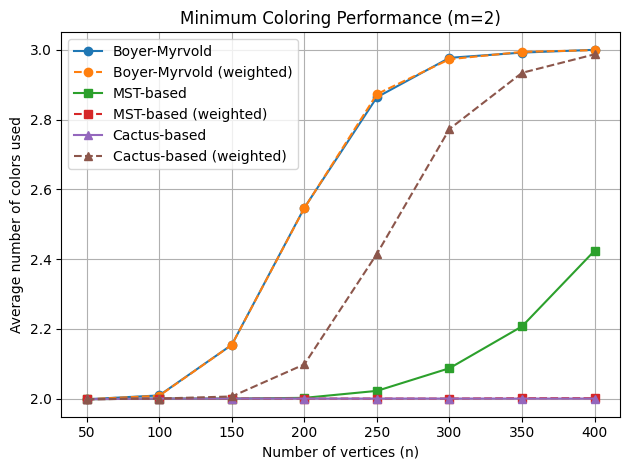

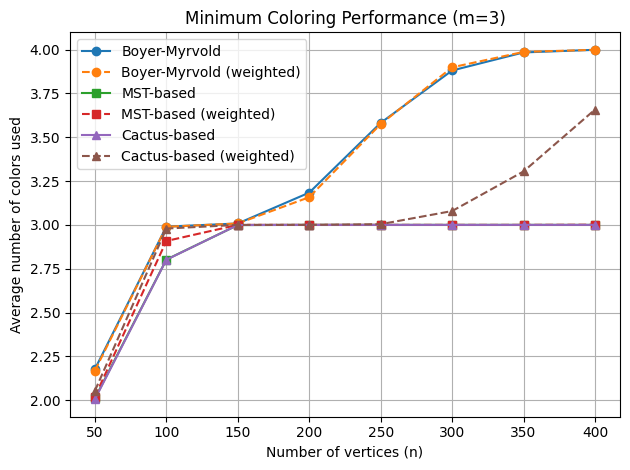

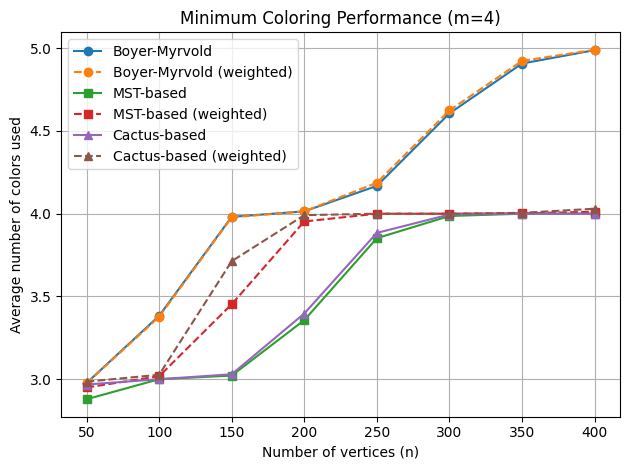

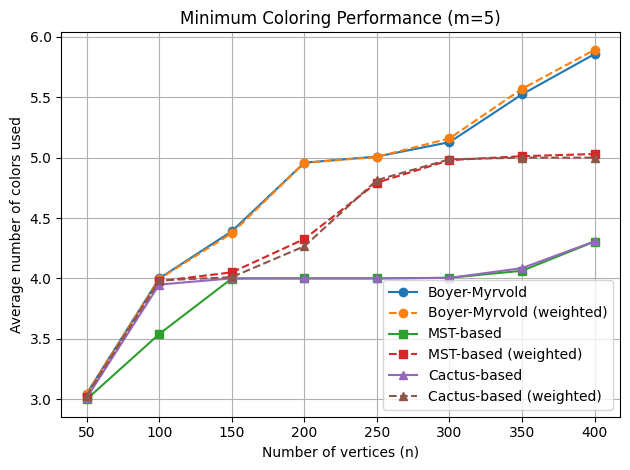

In [16]:
for m in GRAPH_M_VALUES:
    with open(f"cache/minimum_coloring_m{m}.pkl", "rb") as f:
        n_values, results = pickle.load(f)

    results_mean = [r[0] for r in results]
    results_std  = [r[1] for r in results]

    basic_boyer_colors = [res.colors.basic.boyerMyrvold for res in results_mean]
    basic_mst_colors    = [res.colors.basic.mst for res in results_mean]
    basic_cactus_colors = [res.colors.basic.cactus for res in results_mean]

    weighted_boyer_colors= [res.colors.weighted.boyerMyrvold for res in results_mean]
    weighted_mst_colors    = [res.colors.weighted.mst for res in results_mean]
    weighted_cactus_colors = [res.colors.weighted.cactus for res in results_mean]

    plt.plot(n_values, basic_boyer_colors, label="Boyer-Myrvold", marker='o')
    plt.plot(n_values, weighted_boyer_colors, label="Boyer-Myrvold (weighted)", marker='o', linestyle='--')
    plt.plot(n_values, basic_mst_colors, label="MST-based", marker='s')
    plt.plot(n_values, weighted_mst_colors, label="MST-based (weighted)", marker='s', linestyle='--')
    plt.plot(n_values, basic_cactus_colors, label="Cactus-based", marker='^')
    plt.plot(n_values, weighted_cactus_colors, label="Cactus-based (weighted)", marker='^', linestyle='--')
    plt.xlabel("Number of vertices (n)")
    plt.ylabel("Average number of colors used")
    plt.title(f"Minimum Coloring Performance (m={m})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()